In [20]:
!pip -q install open_clip_torch

import json
import os

import matplotlib.pyplot as plt
import numpy as np
import open_clip
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from google.colab import drive
from skimage import color as skcolor
from skimage.metrics import structural_similarity
from sklearn.manifold import TSNE
from sklearn.metrics import f1_score
from torchvision import models
from torchvision.datasets import STL10
from torchvision.transforms import functional as TF

drive.mount("/content/drive")

PROJECT_DIR="/content/drive/MyDrive/ATML-PA1"
DATA_ROOT=PROJECT_DIR+"/data"
os.makedirs(DATA_ROOT,exist_ok=True)
for folder in ["configs","data","models","analysis","scripts","results/figures"]:
    os.makedirs(PROJECT_DIR+"/task1/"+folder,exist_ok=True)
os.chdir(PROJECT_DIR)

if torch.cuda.is_available():
    DEVICE=torch.device("cuda")
else:
    DEVICE=torch.device("cpu")

print(torch.__version__,DEVICE,os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2.11.0+cu128 cuda /content/drive/MyDrive/ATML-PA1


In [21]:
%%writefile task1/configs/task1.yaml
seed: 6304                    #split, eval subset, patch permutations and head init all use this
dataset: stl10
canonical_size: 224           #interventions are built on a common 224x224 RGB image
val_fraction: 0.2             #stratified 80/20 split of the official train split
eval_subset_size: 500         #class-balanced subset of the official test split

Overwriting task1/configs/task1.yaml


In [22]:
CONFIG=yaml.safe_load(open("task1/configs/task1.yaml"))
SEED=CONFIG["seed"]
CANONICAL_SIZE=CONFIG["canonical_size"]


def to_canonical(pil_image):
    """Resize a dataset image to the common 224x224 RGB tensor every intervention starts from STL-10 is 96x96 and square"""
    image=pil_image.convert("RGB")
    image=TF.resize(image,[CANONICAL_SIZE,CANONICAL_SIZE],interpolation=TF.InterpolationMode.BICUBIC)
    return TF.to_tensor(image)


def to_grayscale(image):
    """Drop color entirely"""
    return TF.rgb_to_grayscale(image,num_output_channels=3)


def swap_chroma(image,donor_image):
    """Grayscale asks whether a model needs color; this asks what it does when color actively misleads"""
    source_lab=skcolor.rgb2lab(image.permute(1,2,0).numpy())
    donor_lab=skcolor.rgb2lab(donor_image.permute(1,2,0).numpy())
    result_lab=source_lab.copy()
    for channel in (1,2):
        source_std=source_lab[0:,0:,channel].std()
        if source_std>1e-5:
            scale=donor_lab[0:,0:,channel].std()/source_std
        else:
            scale=0.0
        centred=(source_lab[0:,0:,channel]-source_lab[0:,0:,channel].mean())*scale
        result_lab[0:,0:,channel]=centred+donor_lab[0:,0:,channel].mean()
    return torch.from_numpy(skcolor.lab2rgb(result_lab)).permute(2,0,1).float()


def translate(image,shift,direction):
    """Reflection-pad, then take a crop offset by shift pixels"""
    if shift==0:
        return image.clone()
    padded=F.pad(image.unsqueeze(0),(shift,shift,shift,shift),mode="reflect").squeeze(0)
    offsets={"right":(shift,0),"left":(shift,2*shift),"down":(0,shift),"up":(2*shift,shift)}
    if direction not in offsets:
        raise ValueError(f"unknown direction {direction}")
    row_start,column_start=offsets[direction]
    return padded[0:,row_start:row_start+CANONICAL_SIZE,column_start:column_start+CANONICAL_SIZE]


def random_permutation(random_state,grid_size=4):
    """One non-identity permutation of the grid tiles"""
    tile_count=grid_size*grid_size
    permutation=random_state.permutation(tile_count).tolist()
    while permutation==list(range(tile_count)):
        permutation=random_state.permutation(tile_count).tolist()
    return permutation


def shuffle_patches(image,permutation,grid_size=4):
    """Cut the image into a grid_size x grid_size tiling and paste the tiles back in a new order"""
    patch_size=CANONICAL_SIZE//grid_size
    tiles=[]
    for row in range(grid_size):
        for column in range(grid_size):
            tiles.append(image[0:,row*patch_size:(row+1)*patch_size,column*patch_size:(column+1)*patch_size])
    shuffled=torch.zeros_like(image)
    for destination,source in enumerate(permutation):
        row,column=divmod(destination,grid_size)
        shuffled[0:,row*patch_size:(row+1)*patch_size,column*patch_size:(column+1)*patch_size]=tiles[source]
    return shuffled


print("interventions ready, canonical size",CANONICAL_SIZE,"seed",SEED)

interventions ready, canonical size 224 seed 6304


In [23]:
def stratified_split(labels,val_fraction,seed):
    """Split indices so each class keeps its proportion in both halves. Shuffling happens inside a class which is what makes the split stratified."""
    random_state=np.random.RandomState(seed)
    train_indices=[]
    val_indices=[]
    for class_index in sorted(set(labels.tolist())):
        indices=random_state.permutation(np.where(labels==class_index)[0])
        validation_count=int(round(len(indices)*val_fraction))
        val_indices.extend(indices[0:validation_count].tolist())
        train_indices.extend(indices[validation_count:].tolist())
    return sorted(train_indices),sorted(val_indices)


def balanced_subset(labels,total,seed):
    """Draw total//n_classes images per class and returns the indices and the per-class counts"""
    classes=sorted(set(labels.tolist()))
    per_class=total//len(classes)
    random_state=np.random.RandomState(seed)
    chosen=[]
    counts={}
    for class_index in classes:
        indices=random_state.permutation(np.where(labels==class_index)[0])
        take=min(per_class,len(indices))
        chosen.extend(indices[0:take].tolist())
        counts[int(class_index)]=take
    return sorted(chosen),counts


assert CONFIG["dataset"]=="stl10","the code below only knows how to build the STL-10 splits"
train_set=STL10(root=DATA_ROOT,split="train",download=True)
test_set=STL10(root=DATA_ROOT,split="test",download=True)
CLASSES=list(train_set.classes)

train_indices,val_indices=stratified_split(train_set.labels,CONFIG["val_fraction"],SEED)
eval_indices,eval_counts=balanced_subset(test_set.labels,CONFIG["eval_subset_size"],SEED)
eval_labels=[int(test_set.labels[i]) for i in eval_indices]

SUBSET={
    "seed":SEED,
    "classes":CLASSES,
    "train_indices":train_indices,
    "val_indices":val_indices,
    "eval_indices":eval_indices,
    "eval_counts_per_class":{CLASSES[class_index]:count for class_index,count in eval_counts.items()},
    "train_labels":[int(train_set.labels[i]) for i in train_indices],
    "val_labels":[int(train_set.labels[i]) for i in val_indices],
    "eval_labels":eval_labels
}
json.dump(SUBSET,open("task1/results/subset.json","w"))

print(f"train {len(train_indices)}  val {len(val_indices)}  eval {len(eval_indices)}")
print("eval per class:",SUBSET["eval_counts_per_class"])
!rm -f "$DATA_ROOT/stl10_binary/unlabeled_X.bin"

train 4000  val 1000  eval 500
eval per class: {'airplane': 50, 'bird': 50, 'car': 50, 'cat': 50, 'deer': 50, 'dog': 50, 'horse': 50, 'monkey': 50, 'ship': 50, 'truck': 50}


In [24]:
IMAGENET_MEAN=[0.485,0.456,0.406]
IMAGENET_STD=[0.229,0.224,0.225]
CLIP_MEAN=[0.48145466,0.4578275,0.40821073]
CLIP_STD=[0.26862954,0.26130258,0.27577711]
ZERO_SHOT_PROMPT="a photo of a {}"
FORWARD_BATCH=64


class FrozenBackbone:
    """One pretrained network, frozen, exposing a single features() call"""

    def __init__(self,name):
        self.name=name
        if name=="resnet50":
            self.model=models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
            self.model.fc=nn.Identity()
            self.mean=IMAGENET_MEAN
            self.std=IMAGENET_STD
        elif name=="vit_b_16":
            self.model=models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
            self.model.heads=nn.Identity()
            self.mean=IMAGENET_MEAN
            self.std=IMAGENET_STD
        elif name=="clip":
            self.model,_,_=open_clip.create_model_and_transforms("ViT-B-32-quickgelu",pretrained="openai")
            self.tokenizer=open_clip.get_tokenizer("ViT-B-32-quickgelu")
            self.mean=CLIP_MEAN
            self.std=CLIP_STD
        else:
            raise ValueError(f"unknown backbone {name}")
        self.model=self.model.to(DEVICE).eval()
        for parameter in self.model.parameters():
            parameter.requires_grad=False

    def features(self,images):
        """images is a float tensor (N,3,224,224) in [0,1]"""
        outputs=[]
        for start in range(0,len(images),FORWARD_BATCH):
            batch=images[start:start+FORWARD_BATCH].to(DEVICE)
            batch=TF.normalize(batch,mean=self.mean,std=self.std)
            with torch.no_grad():
                if self.name=="clip":
                    output=self.model.encode_image(batch)
                    output=output/output.norm(dim=-1,keepdim=True)
                else:
                    output=self.model(batch)
            outputs.append(output.float().cpu())
        return torch.cat(outputs,dim=0)

    def text_features(self,class_names):
        """clip only. One l2-normalized text embedding per class from the fixed prompt which is what turns clip into a zero-shot classifier without fitting anything."""
        prompts=[]
        for class_name in class_names:
            prompts.append(ZERO_SHOT_PROMPT.format(class_name))
        tokens=self.tokenizer(prompts).to(DEVICE)
        with torch.no_grad():
            output=self.model.encode_text(tokens)
            output=output/output.norm(dim=-1,keepdim=True)
        return output.float().cpu()


BACKBONES={}
for backbone_name in ["resnet50","vit_b_16","clip"]:
    BACKBONES[backbone_name]=FrozenBackbone(backbone_name)
    print(backbone_name,"loaded")

TEXT_FEATURES=BACKBONES["clip"].text_features(CLASSES)
LOGIT_SCALE=BACKBONES["clip"].model.logit_scale.exp().item()
print("text features",tuple(TEXT_FEATURES.shape),"logit scale",LOGIT_SCALE)

resnet50 loaded
vit_b_16 loaded


clip loaded
text features (10, 512) logit scale 100.0


In [25]:
def extract_features(dataset,indices,block_size=250):
    """Push a list of dataset indices through all three backbones"""
    store={}
    for backbone_name in BACKBONES:
        store[backbone_name]=[]
    for start in range(0,len(indices),block_size):
        block=indices[start:start+block_size]
        images=[]
        for dataset_index in block:
            images.append(to_canonical(dataset[dataset_index][0]))
        images=torch.stack(images)
        for backbone_name,backbone in BACKBONES.items():
            store[backbone_name].append(backbone.features(images))
    result={}
    for backbone_name,chunks in store.items():
        result[backbone_name]=torch.cat(chunks,dim=0)
    return result


train_features=extract_features(train_set,train_indices)
val_features=extract_features(train_set,val_indices)
train_targets=torch.tensor(SUBSET["train_labels"])
val_targets=torch.tensor(SUBSET["val_labels"])
for backbone_name,matrix in train_features.items():
    print(backbone_name,"train",tuple(matrix.shape),"val",tuple(val_features[backbone_name].shape))

resnet50 train (4000, 2048) val (1000, 2048)
vit_b_16 train (4000, 768) val (1000, 768)
clip train (4000, 512) val (1000, 512)


In [26]:
def train_linear_head(train_matrix,train_targets,val_matrix,val_targets,class_count,seed,
                      max_epochs=50,learning_rate=1e-3,weight_decay=1e-4,batch_size=256,patience=5):
    """One linear classifier on frozen features"""
    torch.manual_seed(seed)
    head=nn.Linear(train_matrix.shape[1],class_count)
    optimizer=torch.optim.AdamW(head.parameters(),lr=learning_rate,weight_decay=weight_decay)
    criterion=nn.CrossEntropyLoss()
    best_accuracy=-1.0
    best_state=None
    epochs_without_improvement=0
    for epoch in range(max_epochs):
        head.train()
        order=torch.randperm(len(train_matrix))
        for start in range(0,len(order),batch_size):
            chunk=order[start:start+batch_size]
            optimizer.zero_grad()
            loss=criterion(head(train_matrix[chunk]),train_targets[chunk])
            loss.backward()
            optimizer.step()
        head.eval()
        with torch.no_grad():
            accuracy=(head(val_matrix).argmax(1)==val_targets).float().mean().item()
        if accuracy>best_accuracy:
            best_accuracy=accuracy
            best_state={}
            for key,value in head.state_dict().items():
                best_state[key]=value.clone()
            epochs_without_improvement=0
        else:
            epochs_without_improvement=epochs_without_improvement+1
            if epochs_without_improvement>=patience:
                break
    head.load_state_dict(best_state)
    head.eval()
    return head,best_accuracy,epoch+1


HEADS={}
for backbone_name in BACKBONES:
    head,best_accuracy,epochs_run=train_linear_head(train_features[backbone_name],train_targets,
                                                    val_features[backbone_name],val_targets,
                                                    len(CLASSES),SEED)
    HEADS[backbone_name]=head
    print(f"{backbone_name}: best val accuracy {best_accuracy:.4f} after {epochs_run} epochs")

resnet50: best val accuracy 0.9740 after 20 epochs
vit_b_16: best val accuracy 0.9850 after 29 epochs
clip: best val accuracy 0.9780 after 21 epochs


In [27]:
MODELS={"resnet50":"resnet50","vit_b_16":"vit_b_16","clip_head":"clip","clip_zeroshot":"clip"}


def model_logits(model_name,feature_store):
    """Turn features into logits"""
    features=feature_store[MODELS[model_name]]
    if model_name=="clip_zeroshot":
        return LOGIT_SCALE*features@TEXT_FEATURES.t()
    else:
        with torch.no_grad():
            return HEADS[MODELS[model_name]](features)


def condition_features(images):
    store={}
    for backbone_name,backbone in BACKBONES.items():
        store[backbone_name]=backbone.features(images)
    return store


def score_condition(feature_store,targets):
    """Top-1, macro-F1 and mean maximum confidence for every model on one condition"""
    rows={}
    for model_name in MODELS:
        logits=model_logits(model_name,feature_store)
        probabilities=torch.softmax(logits,dim=1)
        predictions=probabilities.argmax(1)
        rows[model_name]={
            "predictions":predictions,
            "accuracy":(predictions==targets).float().mean().item(),
            "macro_f1":f1_score(targets.numpy(),predictions.numpy(),average="macro"),
            "mean_confidence":probabilities.max(dim=1).values.mean().item()
        }
    return rows


CLEAN_IMAGES=[]
for dataset_index in eval_indices:
    CLEAN_IMAGES.append(to_canonical(test_set[dataset_index][0]))
CLEAN_IMAGES=torch.stack(CLEAN_IMAGES)
eval_targets=torch.tensor(eval_labels)

RESULTS={}
FEATURE_CACHE={}
FEATURE_CACHE["clean"]=condition_features(CLEAN_IMAGES)
RESULTS["clean"]=score_condition(FEATURE_CACHE["clean"],eval_targets)

print(f"{'model':<15}{'top-1':>8}{'macro-F1':>10}{'mean conf':>11}")
for model_name,row in RESULTS["clean"].items():
    print(f"{model_name:<15}{row['accuracy']:>8.4f}{row['macro_f1']:>10.4f}{row['mean_confidence']:>11.4f}")

model             top-1  macro-F1  mean conf
resnet50         0.9660    0.9660     0.9165
vit_b_16         0.9720    0.9721     0.9685
clip_head        0.9660    0.9660     0.3196
clip_zeroshot    0.9680    0.9680     0.9350


In [28]:
def prediction_consistency(condition_name,model_name):
    """Fraction of images whose predicted class is unchanged from the clean image"""
    clean_predictions=RESULTS["clean"][model_name]["predictions"]
    condition_predictions=RESULTS[condition_name][model_name]["predictions"]
    return (clean_predictions==condition_predictions).float().mean().item()


colour_random_state=np.random.RandomState(SEED)
donor_positions=[]
for position in range(len(eval_indices)):
    donor=colour_random_state.randint(len(eval_indices))
    while eval_labels[donor]==eval_labels[position]:
        donor=colour_random_state.randint(len(eval_indices))
    donor_positions.append(donor)

grayscale_images=[]
chroma_images=[]
for position in range(len(eval_indices)):
    grayscale_images.append(to_grayscale(CLEAN_IMAGES[position]))
    chroma_images.append(swap_chroma(CLEAN_IMAGES[position],CLEAN_IMAGES[donor_positions[position]]))
grayscale_images=torch.stack(grayscale_images)
chroma_images=torch.stack(chroma_images)

for condition_name,images in [("grayscale",grayscale_images),("chroma_swap",chroma_images)]:
    FEATURE_CACHE[condition_name]=condition_features(images)
    RESULTS[condition_name]=score_condition(FEATURE_CACHE[condition_name],eval_targets)

print(f"{'model':<15}{'condition':<14}{'top-1':>8}{'change':>9}{'consistency':>13}")
for condition_name in ["grayscale","chroma_swap"]:
    for model_name in MODELS:
        accuracy=RESULTS[condition_name][model_name]["accuracy"]
        change=accuracy-RESULTS["clean"][model_name]["accuracy"]
        consistency=prediction_consistency(condition_name,model_name)
        print(f"{model_name:<15}{condition_name:<14}{accuracy:>8.4f}{change:>+9.4f}{consistency:>13.4f}")

/tmp/ipykernel_861/3298752726.py:31: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 5728 negative Z values that have been clipped to zero
  return torch.from_numpy(skcolor.lab2rgb(result_lab)).permute(2,0,1).float()
/tmp/ipykernel_861/3298752726.py:31: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 31 negative Z values that have been clipped to zero
  return torch.from_numpy(skcolor.lab2rgb(result_lab)).permute(2,0,1).float()
/tmp/ipykernel_861/3298752726.py:31: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 2912 negative Z values that have been clipped to zero
  return torch.from_numpy(skcolor.lab2rgb(result_lab)).permute(2,0,1).float()
/tmp/ipykernel_861/3298752726.py:31: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 146 negative Z values that have been clipped to zero
  return torch.from_numpy(skcolor.lab2rgb(result_lab)).permute(2,0,1).float()
/tmp/ipykernel_

model          condition        top-1   change  consistency
resnet50       grayscale       0.9460  -0.0200       0.9560
vit_b_16       grayscale       0.9520  -0.0200       0.9780
clip_head      grayscale       0.9400  -0.0260       0.9360
clip_zeroshot  grayscale       0.9260  -0.0420       0.9280
resnet50       chroma_swap     0.9380  -0.0280       0.9600
vit_b_16       chroma_swap     0.9600  -0.0120       0.9820
clip_head      chroma_swap     0.9480  -0.0180       0.9700
clip_zeroshot  chroma_swap     0.9540  -0.0140       0.9700


In [29]:
def build_adain_encoder():
    """VGG-19 truncated at relu4_1, in the exact layer order the released AdaIN weights expect. The leading 1x1 convolution is why AdaIN takes images in [0,1] with no ImageNet normalization (sclaing done by itself)"""
    return nn.Sequential(
        nn.Conv2d(3,3,(1,1)),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(3,64,(3,3)),nn.ReLU(),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(64,64,(3,3)),nn.ReLU(),
        nn.MaxPool2d((2,2),(2,2),(0,0),ceil_mode=True),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(64,128,(3,3)),nn.ReLU(),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(128,128,(3,3)),nn.ReLU(),
        nn.MaxPool2d((2,2),(2,2),(0,0),ceil_mode=True),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(128,256,(3,3)),nn.ReLU(),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(256,256,(3,3)),nn.ReLU(),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(256,256,(3,3)),nn.ReLU(),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(256,256,(3,3)),nn.ReLU(),
        nn.MaxPool2d((2,2),(2,2),(0,0),ceil_mode=True),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(256,512,(3,3)),nn.ReLU()
    )


def build_adain_decoder():
    """The mirror of the encoder, trained by the AdaIN authors to invert relu4_1 features back to pixels"""
    return nn.Sequential(
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(512,256,(3,3)),nn.ReLU(),
        nn.Upsample(scale_factor=2,mode="nearest"),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(256,256,(3,3)),nn.ReLU(),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(256,256,(3,3)),nn.ReLU(),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(256,256,(3,3)),nn.ReLU(),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(256,128,(3,3)),nn.ReLU(),
        nn.Upsample(scale_factor=2,mode="nearest"),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(128,128,(3,3)),nn.ReLU(),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(128,64,(3,3)),nn.ReLU(),
        nn.Upsample(scale_factor=2,mode="nearest"),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(64,64,(3,3)),nn.ReLU(),
        nn.ReflectionPad2d((1,1,1,1)),nn.Conv2d(64,3,(3,3))
    )


def adaptive_instance_normalization(content_feature,style_feature):
    content_mean=content_feature.mean(dim=(2,3),keepdim=True)
    content_std=content_feature.std(dim=(2,3),keepdim=True)+1e-5
    style_mean=style_feature.mean(dim=(2,3),keepdim=True)
    style_std=style_feature.std(dim=(2,3),keepdim=True)+1e-5
    normalized=(content_feature-content_mean)/content_std
    return normalized*style_std+style_mean


!wget -q -nc -O task1/results/adain_decoder.pth https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/decoder.pth
!wget -q -nc -O task1/results/adain_vgg.pth https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/vgg_normalised.pth

ADAIN_ENCODER=build_adain_encoder()
encoder_weights=torch.load("task1/results/adain_vgg.pth",map_location="cpu")
kept_weights={}
for key,value in encoder_weights.items():
    if key in ADAIN_ENCODER.state_dict():
        kept_weights[key]=value
print("encoder:",ADAIN_ENCODER.load_state_dict(kept_weights,strict=False))

ADAIN_DECODER=build_adain_decoder()
print("decoder:",ADAIN_DECODER.load_state_dict(torch.load("task1/results/adain_decoder.pth",map_location="cpu")))

ADAIN_ENCODER=ADAIN_ENCODER.to(DEVICE).eval()
ADAIN_DECODER=ADAIN_DECODER.to(DEVICE).eval()

encoder: <All keys matched successfully>
decoder: <All keys matched successfully>


In [30]:
CUE_PAIRS=[("cat","car"),("dog","airplane"),("horse","ship"),("deer","truck"),("bird","monkey")]
PER_PAIR_PER_DIRECTION=50
ACCEPT_CONTENT_SSIM=0.3
ADAIN_ALPHA=1.0
ADAIN_BATCH=16


def stylize(content_images,style_images,alpha=ADAIN_ALPHA):
    """encode both images, replace the content statistics with the style ones, decode (feed forward adain)"""
    outputs=[]
    for start in range(0,len(content_images),ADAIN_BATCH):
        content_batch=content_images[start:start+ADAIN_BATCH].to(DEVICE)
        style_batch=style_images[start:start+ADAIN_BATCH].to(DEVICE)
        with torch.no_grad():
            content_feature=ADAIN_ENCODER(content_batch)
            style_feature=ADAIN_ENCODER(style_batch)
            target=adaptive_instance_normalization(content_feature,style_feature)
            target=alpha*target+(1-alpha)*content_feature
            stylized=ADAIN_DECODER(target)
        outputs.append(stylized.clamp(0.0,1.0).cpu())
    return torch.cat(outputs,dim=0)


def content_similarity(stylized_images,content_images):
    """a stylization that has lost the object keeps almost no structural similarity and such an image cannot express a shape-texture conflict because its shape is gone."""
    scores=[]
    for index in range(len(stylized_images)):
        first=skcolor.rgb2gray(stylized_images[index].permute(1,2,0).numpy())
        second=skcolor.rgb2gray(content_images[index].permute(1,2,0).numpy())
        scores.append(structural_similarity(first,second,data_range=1.0))
    return np.array(scores)


positions_by_class={}
for position in range(len(eval_indices)):
    label=eval_labels[position]
    if label not in positions_by_class:
        positions_by_class[label]=[]
    positions_by_class[label].append(position)

conflict_random_state=np.random.RandomState(SEED)
content_positions=[]
style_positions=[]
conflict_groups=[]
for first_name,second_name in CUE_PAIRS:
    first_class=CLASSES.index(first_name)
    second_class=CLASSES.index(second_name)
    for content_class,style_class in [(first_class,second_class),(second_class,first_class)]:
        content_pool=conflict_random_state.permutation(positions_by_class[content_class])
        style_pool=conflict_random_state.permutation(positions_by_class[style_class])
        for offset in range(PER_PAIR_PER_DIRECTION):
            content_positions.append(int(content_pool[offset]))
            style_positions.append(int(style_pool[offset]))
            conflict_groups.append((content_class,style_class))

content_images=CLEAN_IMAGES[content_positions]
style_images=CLEAN_IMAGES[style_positions]
stylized_images=stylize(content_images,style_images)
ssim_scores=content_similarity(stylized_images,content_images)

for threshold in [0.20,0.25,0.30,0.35,0.40]:
    print(f"threshold {threshold:.2f} would accept {int((ssim_scores>=threshold).sum())}")

accepted=[]
for index in range(len(stylized_images)):
    if ssim_scores[index]>=ACCEPT_CONTENT_SSIM:
        accepted.append(index)

print(f"generated {len(stylized_images)}  accepted {len(accepted)}  rejected {len(stylized_images)-len(accepted)}")
print(f"ssim  median {np.median(ssim_scores):.3f}  range {ssim_scores.min():.3f} to {ssim_scores.max():.3f}")

accepted_by_group={}
for index in accepted:
    group=conflict_groups[index]
    if group not in accepted_by_group:
        accepted_by_group[group]=[]
    accepted_by_group[group].append(index)

per_group=len(accepted)
for members in accepted_by_group.values():
    if len(members)<per_group:
        per_group=len(members)

balanced=[]
for group,members in accepted_by_group.items():
    print(f"{CLASSES[group[0]]:>9} shape / {CLASSES[group[1]]:<9} texture: {len(members)} accepted")
    balanced.extend(members[0:per_group])
accepted=sorted(balanced)
print(f"balanced to {per_group} per pair and direction, {len(accepted)} conflicts total")

threshold 0.20 would accept 476
threshold 0.25 would accept 440
threshold 0.30 would accept 376
threshold 0.35 would accept 273
threshold 0.40 would accept 174
generated 500  accepted 376  rejected 124
ssim  median 0.362  range 0.106 to 0.703
      cat shape / car       texture: 39 accepted
      car shape / cat       texture: 30 accepted
      dog shape / airplane  texture: 42 accepted
 airplane shape / dog       texture: 35 accepted
    horse shape / ship      texture: 44 accepted
     ship shape / horse     texture: 43 accepted
     deer shape / truck     texture: 34 accepted
    truck shape / deer      texture: 23 accepted
     bird shape / monkey    texture: 44 accepted
   monkey shape / bird      texture: 42 accepted
balanced to 23 per pair and direction, 230 conflicts total


model            shape  texture  other  shape bias %  coverage %
resnet50            74       46    110          61.7        52.2
vit_b_16           123       20     87          86.0        62.2
clip_head          131       17     82          88.5        64.3
clip_zeroshot      137       15     78          90.1        66.1


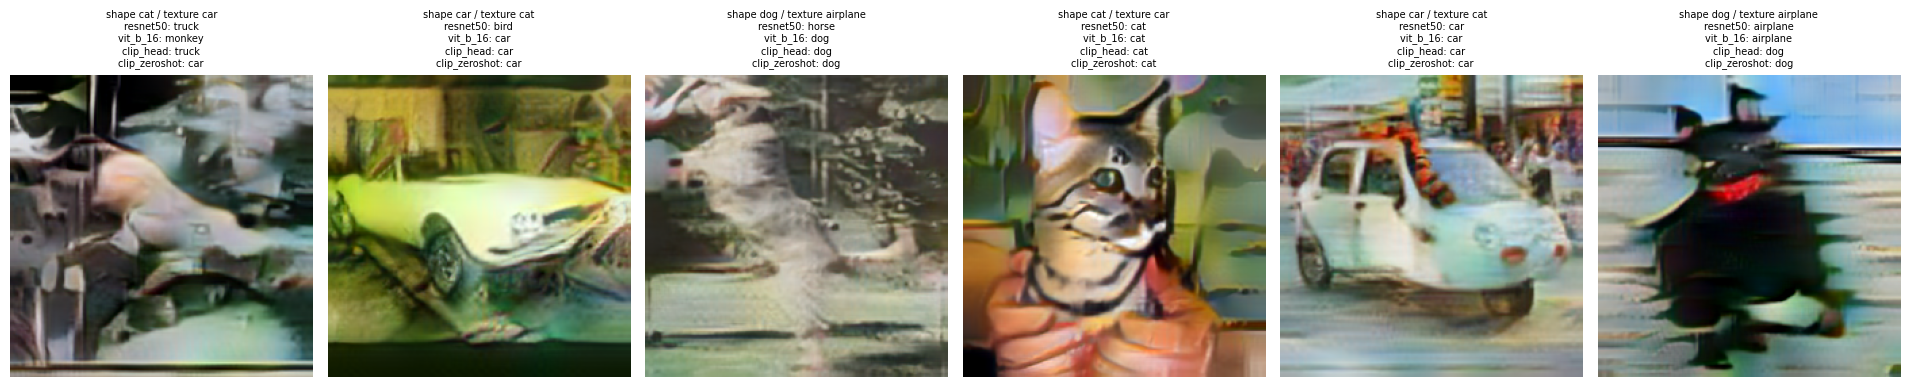

In [34]:
conflict_images=stylized_images[accepted]
conflict_content_labels=torch.tensor([eval_labels[content_positions[index]] for index in accepted])
conflict_style_labels=torch.tensor([eval_labels[style_positions[index]] for index in accepted])
conflict_content_rows=[content_positions[index] for index in accepted]

FEATURE_CACHE["cue_conflict"]=condition_features(conflict_images)

print(f"{'model':<15}{'shape':>7}{'texture':>9}{'other':>7}{'shape bias %':>14}{'coverage %':>12}")
shape_bias_rows={}
for model_name in MODELS:
    predictions=model_logits(model_name,FEATURE_CACHE["cue_conflict"]).argmax(1)
    shape_count=int((predictions==conflict_content_labels).sum())
    texture_count=int((predictions==conflict_style_labels).sum())
    other_count=len(predictions)-shape_count-texture_count
    decided=shape_count+texture_count
    if decided>0:
        shape_bias=100.0*shape_count/decided
    else:
        shape_bias=float("nan")
    coverage=100.0*decided/len(predictions)
    shape_bias_rows[model_name]={"shape":shape_count,"texture":texture_count,"other":other_count,
                                 "shape_bias":shape_bias,"coverage":coverage,"predictions":predictions}
    print(f"{model_name:<15}{shape_count:>7}{texture_count:>9}{other_count:>7}{shape_bias:>14.1f}{coverage:>12.1f}")

def pick_examples(indices,count):
    """Take at most one example per class pair so the figure spans the conflict set rather than
    showing six versions of whichever pair happens to come first."""
    used=set()
    chosen=[]
    for index in indices:
        pair=(int(conflict_content_labels[index]),int(conflict_style_labels[index]))
        if pair not in used:
            used.add(pair)
            chosen.append(index)
        if len(chosen)==count:
            break
    return chosen
agree=[]
disagree=[]
for index in range(len(conflict_images)):
    if shape_bias_rows["resnet50"]["predictions"][index]==shape_bias_rows["vit_b_16"]["predictions"][index]:
        agree.append(index)
    else:
        disagree.append(index)
chosen=pick_examples(disagree,3)+pick_examples(agree,3)

figure,axes=plt.subplots(1,len(chosen),figsize=(3.2*len(chosen),5.5))
for axis,index in zip(axes,chosen):
    axis.imshow(conflict_images[index].permute(1,2,0).numpy())
    caption=f"shape {CLASSES[conflict_content_labels[index]]} / texture {CLASSES[conflict_style_labels[index]]}"
    for model_name,row in shape_bias_rows.items():
        caption=caption+f"\n{model_name}: {CLASSES[row['predictions'][index]]}"
    axis.set_title(caption,fontsize=7)
    axis.axis("off")
figure.tight_layout()
figure.savefig("task1/results/figures/cue_conflicts.png",dpi=150)
plt.show()

shift 0 done
shift 8 done
shift 16 done
shift 32 done


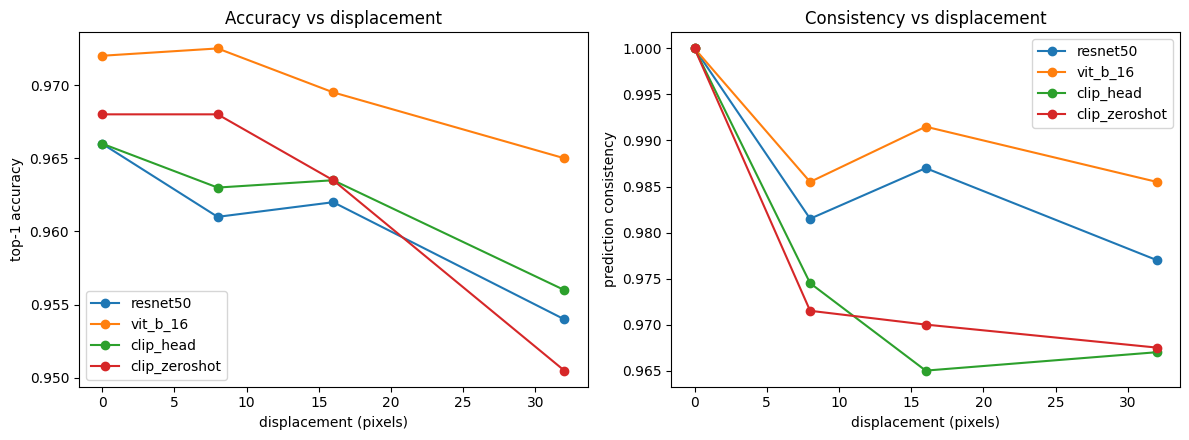

In [36]:
TRANSLATION_SHIFTS=[0,8,16,32]
TRANSLATION_DIRECTIONS=["up","down","left","right"]

translation_accuracy={}
translation_consistency={}
for model_name in MODELS:
    translation_accuracy[model_name]=[]
    translation_consistency[model_name]=[]

for shift in TRANSLATION_SHIFTS:
    if shift==0:
        for model_name in MODELS:
            translation_accuracy[model_name].append(RESULTS["clean"][model_name]["accuracy"])
            translation_consistency[model_name].append(1.0)
    else:
        accuracy_sum={}
        consistency_sum={}
        for model_name in MODELS:
            accuracy_sum[model_name]=0.0
            consistency_sum[model_name]=0.0
        for direction in TRANSLATION_DIRECTIONS:
            images=[]
            for position in range(len(eval_indices)):
                images.append(translate(CLEAN_IMAGES[position],shift,direction))
            images=torch.stack(images)
            condition_name=f"translate_{shift}_{direction}"
            FEATURE_CACHE[condition_name]=condition_features(images)
            RESULTS[condition_name]=score_condition(FEATURE_CACHE[condition_name],eval_targets)
            for model_name in MODELS:
                accuracy_sum[model_name]=accuracy_sum[model_name]+RESULTS[condition_name][model_name]["accuracy"]
                consistency_sum[model_name]=consistency_sum[model_name]+prediction_consistency(condition_name,model_name)
        for model_name in MODELS:
            translation_accuracy[model_name].append(accuracy_sum[model_name]/len(TRANSLATION_DIRECTIONS))
            translation_consistency[model_name].append(consistency_sum[model_name]/len(TRANSLATION_DIRECTIONS))
    print("shift",shift,"done")

figure,axes=plt.subplots(1,2,figsize=(12,4.5))
for model_name in MODELS:
    axes[0].plot(TRANSLATION_SHIFTS,translation_accuracy[model_name],marker="o",label=model_name)
    axes[1].plot(TRANSLATION_SHIFTS,translation_consistency[model_name],marker="o",label=model_name)
axes[0].set_xlabel("displacement (pixels)")
axes[0].set_ylabel("top-1 accuracy")
axes[0].set_title("Accuracy vs displacement")
axes[0].legend()
axes[1].set_xlabel("displacement (pixels)")
axes[1].set_ylabel("prediction consistency")
axes[1].set_title("Consistency vs displacement")
axes[1].legend()
figure.tight_layout()
figure.savefig("task1/results/figures/translation.png",dpi=150)
plt.show()

In [37]:
shuffle_random_state=np.random.RandomState(SEED)
patch_permutations=[]
shuffled_images=[]
for position in range(len(eval_indices)):
    permutation=random_permutation(shuffle_random_state)
    patch_permutations.append(permutation)
    shuffled_images.append(shuffle_patches(CLEAN_IMAGES[position],permutation))
shuffled_images=torch.stack(shuffled_images)

FEATURE_CACHE["patch_shuffle"]=condition_features(shuffled_images)
RESULTS["patch_shuffle"]=score_condition(FEATURE_CACHE["patch_shuffle"],eval_targets)

print(f"{'model':<15}{'top-1':>8}{'change':>9}{'consistency':>13}{'mean conf':>11}")
for model_name in MODELS:
    accuracy=RESULTS["patch_shuffle"][model_name]["accuracy"]
    change=accuracy-RESULTS["clean"][model_name]["accuracy"]
    consistency=prediction_consistency("patch_shuffle",model_name)
    confidence=RESULTS["patch_shuffle"][model_name]["mean_confidence"]
    print(f"{model_name:<15}{accuracy:>8.4f}{change:>+9.4f}{consistency:>13.4f}{confidence:>11.4f}")

model             top-1   change  consistency  mean conf
resnet50         0.8740  -0.0920       0.8980     0.8880
vit_b_16         0.9060  -0.0660       0.9220     0.8983
clip_head        0.8540  -0.1120       0.8580     0.2244
clip_zeroshot    0.8240  -0.1440       0.8340     0.8147


In [38]:
def cosine_stability(condition_name,backbone_name,rows=None):
    """Mean cosine similarity between each transformed image's feature vector and its own clean counterpart"""
    clean_matrix=FEATURE_CACHE["clean"][backbone_name]
    condition_matrix=FEATURE_CACHE[condition_name][backbone_name]
    if rows is not None:
        clean_matrix=clean_matrix[rows]
    return F.cosine_similarity(clean_matrix,condition_matrix,dim=1).mean().item()


STABILITY_SHIFT=16
stability_rows={}
for backbone_name in BACKBONES:
    translation_values=[]
    for direction in TRANSLATION_DIRECTIONS:
        translation_values.append(cosine_stability(f"translate_{STABILITY_SHIFT}_{direction}",backbone_name))
    stability_rows[backbone_name]={
        "grayscale":cosine_stability("grayscale",backbone_name),
        "chroma_swap":cosine_stability("chroma_swap",backbone_name),
        "cue_conflict":cosine_stability("cue_conflict",backbone_name,conflict_content_rows),
        f"translate_{STABILITY_SHIFT}":sum(translation_values)/len(translation_values),
        "patch_shuffle":cosine_stability("patch_shuffle",backbone_name)
    }

stability_conditions=["grayscale","chroma_swap","cue_conflict",f"translate_{STABILITY_SHIFT}","patch_shuffle"]
print(f"{'backbone':<12}"+"".join([f"{name:>16}" for name in stability_conditions]))
for backbone_name,row in stability_rows.items():
    print(f"{backbone_name:<12}"+"".join([f"{row[name]:>16.4f}" for name in stability_conditions]))

backbone           grayscale     chroma_swap    cue_conflict    translate_16   patch_shuffle
resnet50              0.7885          0.9121          0.2822          0.9531          0.7153
vit_b_16              0.7369          0.9141          0.2715          0.9745          0.6572
clip                  0.9002          0.9554          0.6644          0.9678          0.7260


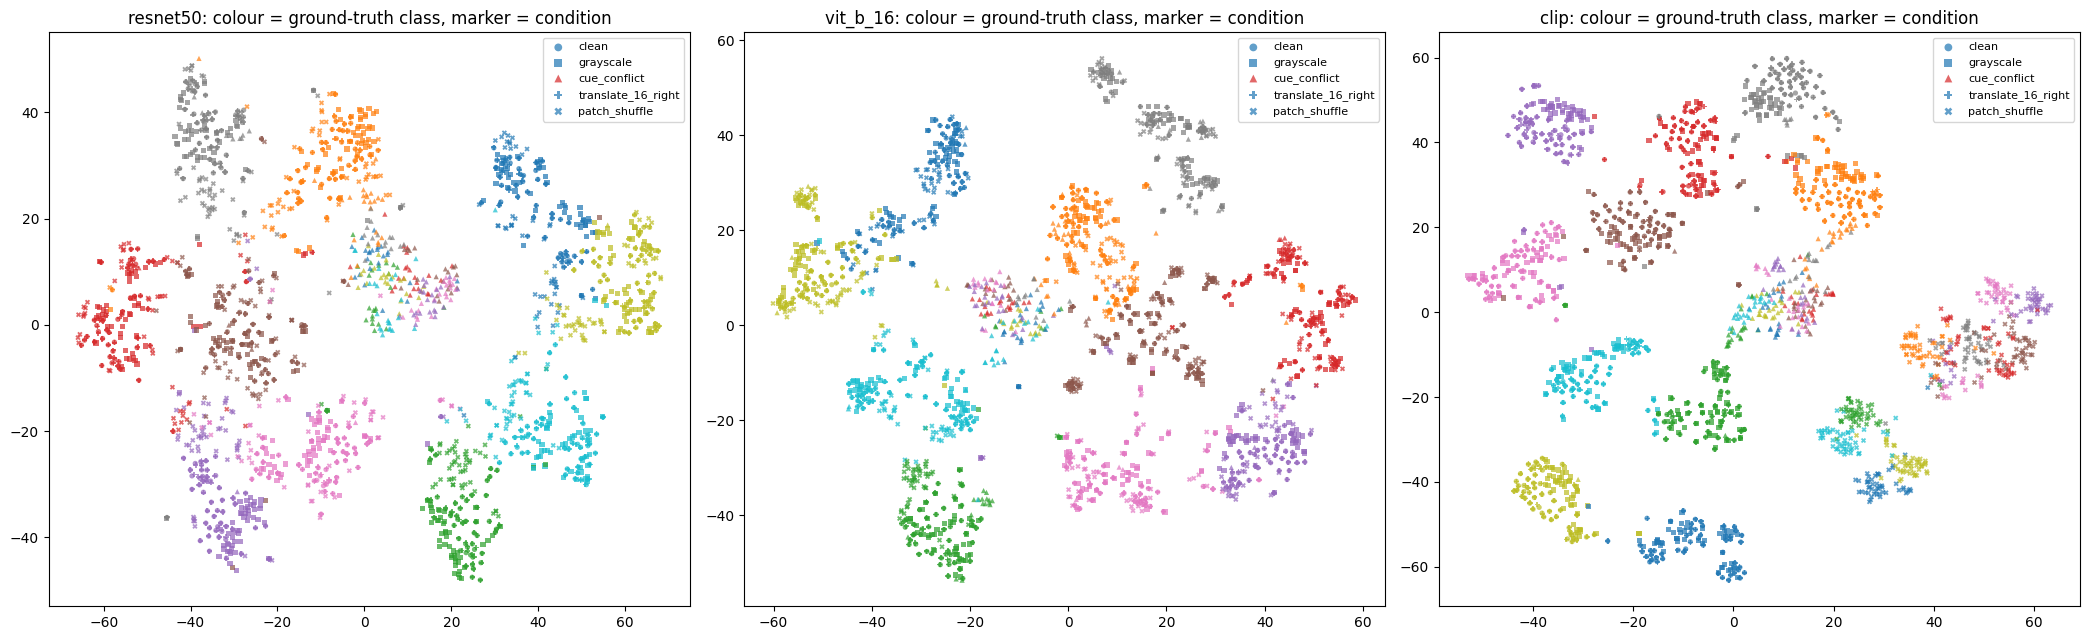

In [39]:
PROJECTION_CONDITIONS=["clean","grayscale","cue_conflict",f"translate_{STABILITY_SHIFT}_right","patch_shuffle"]
PROJECTION_MARKERS={"clean":"o","grayscale":"s","cue_conflict":"^",
                    f"translate_{STABILITY_SHIFT}_right":"P","patch_shuffle":"X"}

figure,axes=plt.subplots(1,len(BACKBONES),figsize=(7*len(BACKBONES),6.5))
for axis,backbone_name in zip(axes,BACKBONES):
    matrices=[]
    point_labels=[]
    point_conditions=[]
    for condition_name in PROJECTION_CONDITIONS:
        matrix=FEATURE_CACHE[condition_name][backbone_name]
        matrices.append(matrix)
        if condition_name=="cue_conflict":
            point_labels.append(conflict_content_labels)
        else:
            point_labels.append(eval_targets)
        point_conditions.extend([condition_name]*len(matrix))
    combined=torch.cat(matrices,dim=0)
    point_labels=torch.cat(point_labels,dim=0).numpy()
    point_conditions=np.array(point_conditions)

    centred=combined-combined.mean(dim=0,keepdim=True)
    _,_,components=torch.pca_lowrank(centred,q=50)
    reduced=(centred@components).numpy()
    embedding=TSNE(n_components=2,perplexity=30,init="pca",random_state=SEED).fit_transform(reduced)

    colours=plt.get_cmap("tab10")
    for condition_name in PROJECTION_CONDITIONS:
        mask=point_conditions==condition_name
        axis.scatter(embedding[mask,0],embedding[mask,1],c=colours(point_labels[mask]%10),
                     marker=PROJECTION_MARKERS[condition_name],s=14,alpha=0.7,
                     label=condition_name,linewidths=0)
    axis.set_title(f"{backbone_name}: colour = ground-truth class, marker = condition")
    axis.legend(markerscale=1.5,fontsize=8,loc="best")
figure.tight_layout()
figure.savefig("task1/results/figures/tsne.png",dpi=150)
plt.show()

In [40]:
summary={"seed":SEED,"classes":CLASSES,"conditions":{},"shape_bias":{},"cosine_stability":stability_rows,
         "translation":{"shifts":TRANSLATION_SHIFTS,"accuracy":translation_accuracy,
                        "consistency":translation_consistency},
         "cue_conflict":{"generated":len(stylized_images),"accepted":len(accepted),
                         "rejected":len(stylized_images)-len(accepted),
                         "accept_content_ssim":ACCEPT_CONTENT_SSIM,
                         "pairs":[list(pair) for pair in CUE_PAIRS]},
         "patch_permutations":patch_permutations,"chroma_donor_positions":donor_positions}

for condition_name,rows in RESULTS.items():
    summary["conditions"][condition_name]={}
    for model_name,row in rows.items():
        summary["conditions"][condition_name][model_name]={
            "accuracy":row["accuracy"],"macro_f1":row["macro_f1"],
            "mean_confidence":row["mean_confidence"],
            "consistency_with_clean":prediction_consistency(condition_name,model_name),
            "predictions":row["predictions"].tolist()
        }

for model_name,row in shape_bias_rows.items():
    summary["shape_bias"][model_name]={"shape":row["shape"],"texture":row["texture"],"other":row["other"],
                                       "shape_bias":row["shape_bias"],"coverage":row["coverage"],
                                       "predictions":row["predictions"].tolist()}

json.dump(summary,open("task1/results/task1_results.json","w"),indent=1)
print("wrote task1/results/task1_results.json")
print("conditions recorded:",len(summary["conditions"]))

wrote task1/results/task1_results.json
conditions recorded: 16
